# Insight: Marital status per area

**Question:** Check marital status per area.

**Data source:** `Cuisine_rating_clean.csv` (the single cleaned dataset version produced by the dataset-cleanup skill — no `_v2`/`_v3` siblings exist). `Location` has already been normalized during cleaning: casing/typo variants merged and comma-spacing standardized, leaving 8 real locations (not the original 10).

**Relevant columns:** `Location`, `Marital Status`.

**Scope confirmed:** full 200-row dataset, no filtering. This is a composition/distribution question (how marital-status mix varies by area), not a ratings question.

## Assumptions

- "Area" = the `Location` column (8 cleaned values: `St. George,NY`, `Upper East Side,NY`, `Riverdale,NY`, `Central Park,NY`, `China Town,NY`, `Market City,NY`, `Upper West Side,NY`, `Cedar Hill,NY`).
- "Marital status" = the `Marital Status` column (`Single` / `Married` / `Divorced`).
- No time window or additional filters implied by the question.

In [1]:
import pandas as pd
from scipy.stats import chi2_contingency
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

cat_cols = ['Location', 'Gender', 'Marital Status', 'Activity', 'Cuisines', 'Alcohol', 'Smoker', 'Often A S']
df = pd.read_csv('Cuisine_rating_clean.csv')
df.columns = [c.strip() for c in df.columns]
for c in cat_cols:
    df[c] = df[c].astype('category')

print('Shape:', df.shape)
df['Location'].value_counts()

Shape: (200, 15)


Location
St. George,NY         46
Central Park,NY       32
Upper East Side,NY    30
Riverdale,NY          28
China Town,NY         22
Market City,NY        22
Upper West Side,NY    18
Cedar Hill,NY          2
Name: count, dtype: int64

## Analysis

In [2]:
counts = pd.crosstab(df['Location'], df['Marital Status'])
counts = counts.reindex(df['Location'].value_counts().index)
counts

Marital Status,Divorced,Married,Single
Location,,,
"St. George,NY",4,16,26
"Central Park,NY",2,4,26
"Upper East Side,NY",2,16,12
"Riverdale,NY",0,12,16
"China Town,NY",2,10,10
"Market City,NY",2,16,4
"Upper West Side,NY",2,10,6
"Cedar Hill,NY",0,2,0


In [3]:
row_pct = pd.crosstab(df['Location'], df['Marital Status'], normalize='index') * 100
row_pct = row_pct.reindex(df['Location'].value_counts().index).round(1)
print('Row percentages (marital-status mix within each location):')
row_pct

Row percentages (marital-status mix within each location):


Marital Status,Divorced,Married,Single
Location,,,
"St. George,NY",8.7,34.8,56.5
"Central Park,NY",6.2,12.5,81.2
"Upper East Side,NY",6.7,53.3,40.0
"Riverdale,NY",0.0,42.9,57.1
"China Town,NY",9.1,45.5,45.5
"Market City,NY",9.1,72.7,18.2
"Upper West Side,NY",11.1,55.6,33.3
"Cedar Hill,NY",0.0,100.0,0.0


In [4]:
overall_mix = (df['Marital Status'].value_counts(normalize=True) * 100).round(1)
print('Overall dataset mix (baseline to compare each location against):')
overall_mix

Overall dataset mix (baseline to compare each location against):


Marital Status
Single      50.0
Married     43.0
Divorced     7.0
Name: proportion, dtype: float64

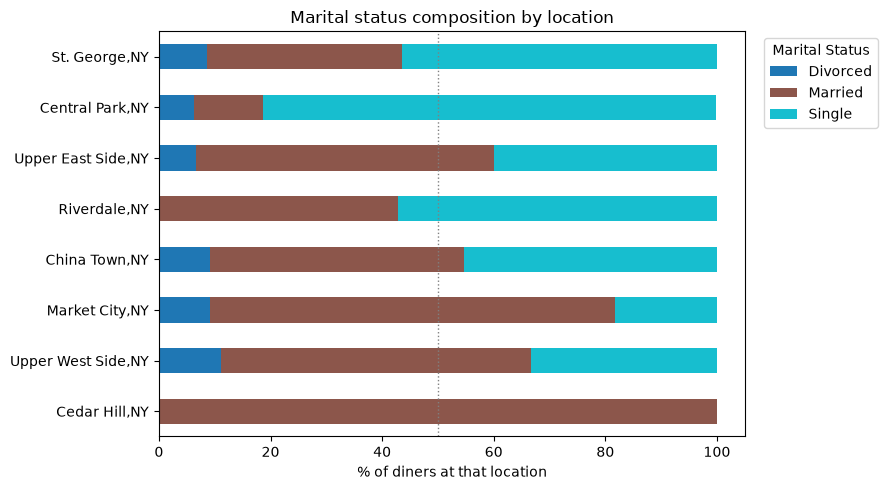

In [5]:
import matplotlib.pyplot as plt

ax = row_pct.loc[df['Location'].value_counts().index[::-1]].plot(
    kind='barh', stacked=True, figsize=(9, 5), colormap='tab10'
)
ax.set_xlabel('% of diners at that location')
ax.set_ylabel('')
ax.set_title('Marital status composition by location')
ax.axvline(overall_mix['Single'], color='gray', linestyle=':', linewidth=1)
ax.legend(title='Marital Status', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [6]:
chi2, p, dof, expected = chi2_contingency(counts)
n_cells = expected.size
n_low = (expected < 5).sum()
print(f'Chi-square test of independence (Location x Marital Status): chi2={chi2:.2f}, dof={dof}, p={p:.4f}')
print(f'{n_low}/{n_cells} cells ({n_low/n_cells*100:.0f}%) have an expected count below 5')

counts_no_cedar = counts.drop(index='Cedar Hill,NY')
chi2b, pb, dofb, expected_b = chi2_contingency(counts_no_cedar)
n_low_b = (expected_b < 5).sum()
print(f"\nExcluding Cedar Hill,NY (n=2, the thinnest location): chi2={chi2b:.2f}, dof={dofb}, p={pb:.4f}")
print(f'{n_low_b}/{expected_b.size} cells ({n_low_b/expected_b.size*100:.0f}%) still below expected count 5')

Chi-square test of independence (Location x Marital Status): chi2=32.21, dof=14, p=0.0037
10/24 cells (42%) have an expected count below 5

Excluding Cedar Hill,NY (n=2, the thinnest location): chi2=29.56, dof=12, p=0.0032
7/21 cells (33%) still below expected count 5


## Confidence & caveats

- **The chi-square result should be read as directional, not conclusive.** A standard rule of thumb requires no more than ~20% of cells to have an expected count under 5; here **42% of the 24 cells** are below that threshold (min expected count 0.14, for Cedar Hill × Divorced). Even after excluding `Cedar Hill,NY` (the thinnest location, n=2) entirely, **33% of remaining cells** are still under 5. The p-value (0.0037, or 0.0032 excluding Cedar Hill) is consistent across both versions, which adds some confidence the pattern is real, but a formal chi-square isn't fully valid on this sparse a table — treat the significance as suggestive, not proof.
- **`Cedar Hill,NY` (n=2) is too small to characterize at all** — both diners happened to be Married, but that's not a meaningful "100% Married" claim.
- **`Divorced` is rare overall (14 of 200, 7%)**, so it's spread thin across 8 locations — most locations have 0-4 divorced diners, making any location's "Divorced share" noisy individually. The Married/Single split is where the sample sizes support a real read.
- Two locations stand out with reasonably large n behind them, which is where this finding is strongest:
  - **`Central Park,NY`** (n=32): 81.2% Single — far above the overall 50.0% baseline.
  - **`Market City,NY`** (n=22): 72.7% Married — far above the overall 43.0% baseline.
- `Riverdale,NY` (n=28) has zero Divorced diners, which is notable but could plausibly be sampling noise given only ~2 divorced diners would be expected there under the overall rate.

## Conclusion

**Marital status is not evenly spread across locations — it clusters.** The clearest, best-supported patterns:

- **`Central Park,NY` skews heavily Single** (81.2% vs. a 50.0% dataset-wide average) — the strongest single-location skew in the data, and backed by a decent sample (n=32).
- **`Market City,NY` skews heavily Married** (72.7% vs. 43.0% overall), also on a reasonable sample (n=22).
- The remaining locations (`St. George,NY`, `Upper East Side,NY`, `Riverdale,NY`, `China Town,NY`, `Upper West Side,NY`) sit closer to the overall mix, with `Riverdale,NY` notably having zero Divorced diners.
- `Cedar Hill,NY` (n=2) is too small to say anything about.

A chi-square test across all 8 locations is statistically significant (p=0.0037) and holds up even after removing the smallest location, but the contingency table is sparse enough (42% of cells with expected count under 5) that this should be treated as **supporting evidence for a real pattern, not formal proof** — the two standout locations above are the load-bearing part of the finding, not the omnibus test by itself.

## Flagged follow-ups

- **Relevant to the smoking/food-rating confound raised in `01_smoking_food_enjoyment.ipynb`:** that notebook found `Often` smokers rate food much higher (4.10) than `Never`/`Socially` smokers, and flagged Marital Status as a plausible confounder since Divorced diners also rate notably higher on average. This notebook shows marital-status composition *does* vary meaningfully by `Location` (Central Park skews Single, Market City skews Married) — so if `Smoker` status also happens to vary by `Location`, that would be a plausible indirect channel worth checking. This notebook doesn't test that chain directly; a dedicated follow-up crossing `Smoker` x `Marital Status` x `Location` together (or a simple `Smoker` x `Location` crosstab) would be needed to actually confirm or rule it out.
- Given the small Divorced sample (14 total), a follow-up with a stricter test (e.g. Fisher's exact test on 2-location-at-a-time comparisons, or collapsing to Married-vs-not) could firm up whether the Central Park / Market City patterns specifically are robust, independent of the sparse omnibus chi-square.

- **Cross-check against `04_yob_budget_area.ipynb` (already completed):** that notebook independently found `Central Park,NY` skews youngest (mean age 35.7) and `Market City,NY` skews oldest (mean age 48.7) by age — which lines up naturally with this notebook's finding that the same two locations skew Single and Married respectively. The age result and the marital-status result corroborate each other, which is a good consistency signal even though neither notebook tested age and marital status jointly.